### 1. Packages

In [24]:
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import TweedieRegressor
from sklearn.linear_model import PoissonRegressor
import pandas as pd
import matplotlib.pyplot as plt


### 2. Constructing a dataset

We simulate **bike-share usage**: each row is one **docking station on one summer day**. The response is how many trips started that day at that station (`daily_trips`). Predictors are the day’s **high temperature** (`temp_high_c`, °C) and **total rainfall** (`rain_mm`).

**Counts are drawn from a Poisson distribution** with a log-linear mean. That is *not* compatible with standard linear regression’s usual setup of **approximately normal, homoscedastic errors** on a continuous response: here \(Y\) is **nonnegative integers**, **right-skewed** (especially when mean counts are small), and **variance grows with the mean** (heteroscedasticity). This notebook uses **larger expected counts** so the marginal histogram is still skewed but Pearson residual diagnostics (e.g. Q–Q) read clearly under the true Poisson model. Plain OLS on `daily_trips` remains a deliberate mismatch; a GLM (e.g. Poisson / log link) matches the sampling story. The **Data exploration** section at the end shows a histogram of the response, a preview of `df`, and mean–variance diagnostics supporting a Poisson model.


In [25]:
rng = np.random.default_rng(42)
n = 12000

# One row = one bike-share dock on one day during a warm season (synthetic).
# Larger n and moderately large Poisson means: Pearson residuals are closer to normal
# in Q–Q plots when the log-linear Poisson model is correctly specified.
temp_high_c = rng.normal(24.0, 3.5, size=n)
rain_mm = rng.exponential(scale=2.0, size=n)  # mostly dry days, occasional rain

# log(E[daily_trips]) = beta0 + beta1*(temp - 24) + beta2*rain
# Baseline μ is chosen so typical counts are not tiny (reduces discrete noise in residuals).
beta0 = np.log(22.0)
beta1 = 0.045
beta2 = -0.085

eta = beta0 + beta1 * (temp_high_c - 24.0) + beta2 * rain_mm
mu = np.exp(eta)
daily_trips = rng.poisson(mu)

df = pd.DataFrame(
    {
        "daily_trips": daily_trips,
        "temp_high_c": temp_high_c,
        "rain_mm": rain_mm,
    }
)
feature_cols = ["temp_high_c", "rain_mm"]
X = df[feature_cols]
y = df["daily_trips"]

# Keep simulation truth μ on the dataframe for the Data exploration section.
df["_sim_mu"] = mu


### 3. Fit OLR

In [26]:
ols = LinearRegression().fit(X, y)
fitted = ols.predict(X)
residuals = y - fitted

### 4. Checking OLS assumptions

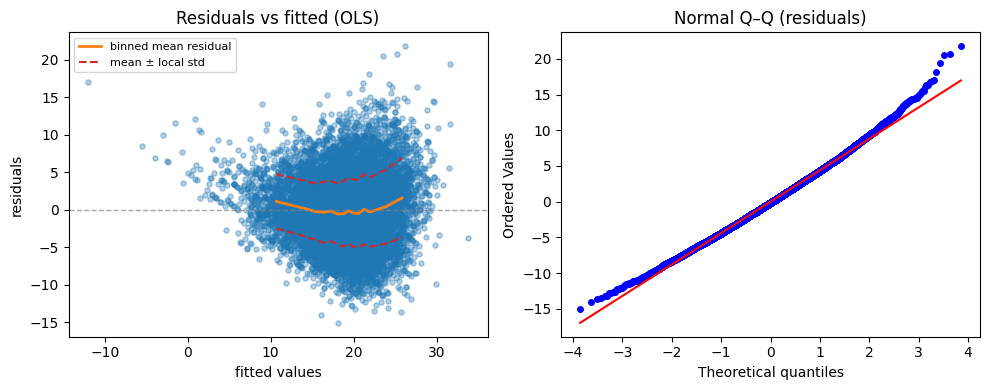

             daily_trips  temp_high_c  rain_mm
daily_trips       1.0000       0.5018  -0.4572
temp_high_c       0.5018       1.0000   0.0062
rain_mm          -0.4572       0.0062   1.0000


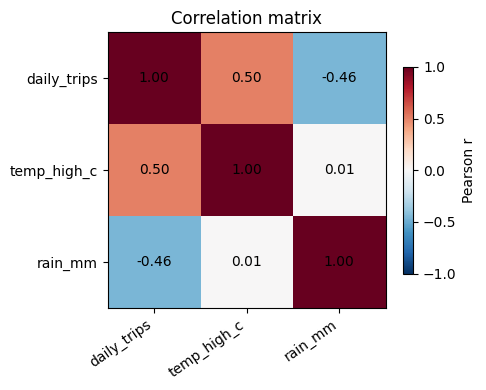

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(fitted, residuals, alpha=0.35, s=14)

# Binned mean residual (local average) and mean ± local std (local spread)
_fit = np.asarray(fitted).ravel()
_res = np.asarray(residuals).ravel()
_bin = pd.qcut(_fit, q=15, duplicates="drop")
_summary = (
    pd.DataFrame({"fitted": _fit, "residual": _res, "bin": _bin})
    .groupby("bin", observed=True)
    .agg(f_mid=("fitted", "median"), m=("residual", "mean"), s=("residual", "std"))
    .reset_index(drop=True)
)
_summary["s"] = _summary["s"].fillna(0)
axes[0].plot(_summary["f_mid"], _summary["m"], color="C1", lw=2, label="binned mean residual")
axes[0].plot(
    _summary["f_mid"],
    _summary["m"] + _summary["s"],
    color="C3",
    ls="--",
    lw=1.5,
    label="mean ± local std",
)
axes[0].plot(_summary["f_mid"], _summary["m"] - _summary["s"], color="C3", ls="--", lw=1.5)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
axes[0].set_xlabel("fitted values")
axes[0].set_ylabel("residuals")
axes[0].set_title("Residuals vs fitted (OLS)")
axes[0].legend(loc="best", fontsize=8)

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q–Q (residuals)")
axes[1].get_lines()[0].set_markersize(4)
plt.tight_layout()
plt.show()

corr = df[["daily_trips", "temp_high_c", "rain_mm"]].corr()
print(corr.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=35, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

### 5. Additional Data exploration

**Why a Poisson GLM?** The response is **nonnegative integer counts**, often **skewed** (histogram below). For Poisson data, **Var(Y | x) = E[Y | x] = μ(x)**. When we group rows with **similar μ(x)** (here, simulation truth `_sim_mu`), the **sample variance and sample mean of y** in each bin should be **close**—that **mean–variance link** is what Poisson regression encodes. (The **marginal** variance/mean ratio need **not** be 1 when μ(x) varies across rows.)


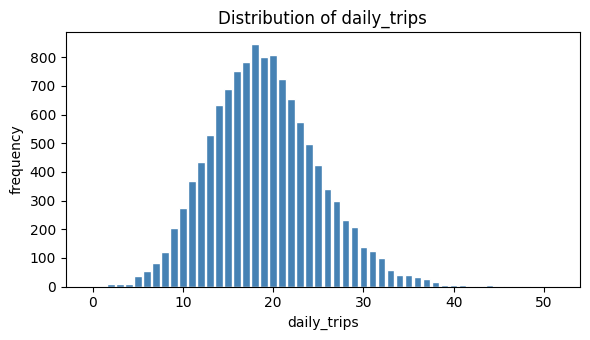

   daily_trips  temp_high_c   rain_mm    _sim_mu
0           20    25.066510  1.302626  20.662328
1           10    20.360056  4.298481  12.960082
2           15    26.626579  2.092443  20.725833
3           12    27.291977  8.427909  12.463559
4            8    17.171377  4.426433  11.106246
Marginal mean of daily_trips: 19.0405
Marginal variance of daily_trips: 36.254
Marginal variance / mean: 1.904 (not the Poisson check when μ(x) varies across rows.)
Average Var(Y|x) if Poisson (= mean μ(x), simulation truth): 19.0002

Within bins of similar μ = E[Y|x] (simulation truth):
 y_mean   y_var  mu_mean  var_over_mean
 11.395 14.8318  11.3778         1.3016
 14.468 13.8508  14.3536         0.9573
 15.728 15.7237  15.7485         0.9997
 16.925 16.4158  16.7864         0.9699
 17.553 16.5377  17.7007         0.9422
 18.606 17.7505  18.5690         0.9540
 19.552 20.7901  19.3793         1.0633
 19.979 19.6762  20.2015         0.9848
 21.353 22.4108  21.1330         1.0495
 22.175 22.0444  

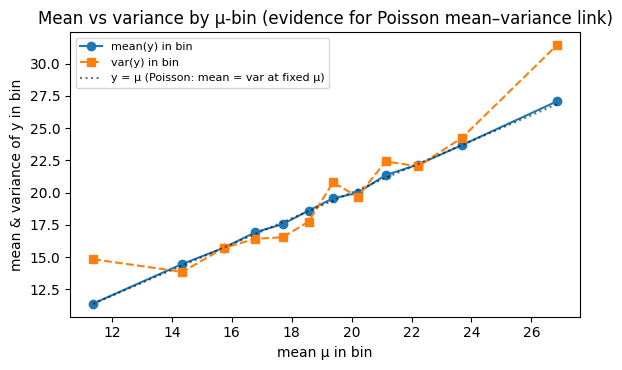

In [28]:
_mx = int(df["daily_trips"].max())
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(
    df["daily_trips"],
    bins=np.arange(-0.5, _mx + 1.5, 1),
    rwidth=0.85,
    color="steelblue",
    edgecolor="white",
)
ax.set_xlabel("daily_trips")
ax.set_ylabel("frequency")
ax.set_title("Distribution of daily_trips")
plt.tight_layout()
plt.show()

print(df.head())

_m = df["daily_trips"]
_mu = df["_sim_mu"]

_marg_m = float(_m.mean())
_marg_v = float(_m.var())
print("Marginal mean of daily_trips:", round(_marg_m, 4))
print("Marginal variance of daily_trips:", round(_marg_v, 4))
print(
    "Marginal variance / mean:",
    round(_marg_v / _marg_m, 4),
    "(not the Poisson check when μ(x) varies across rows.)",
)
print(
    "Average Var(Y|x) if Poisson (= mean μ(x), simulation truth):",
    round(float(_mu.mean()), 4),
)

_diag = (
    pd.DataFrame({"y": _m, "mu": _mu})
    .assign(bin=pd.qcut(_mu, q=12, duplicates="drop"))
    .groupby("bin", observed=True)
    .agg(y_mean=("y", "mean"), y_var=("y", "var"), mu_mean=("mu", "mean"))
    .reset_index(drop=True)
)
_diag["y_var"] = _diag["y_var"].fillna(0)
_diag["var_over_mean"] = (_diag["y_var"] / _diag["y_mean"]).replace([float("inf"), float("-inf")], 0)
print("\nWithin bins of similar μ = E[Y|x] (simulation truth):")
print(_diag.round(4).to_string(index=False))
print(
    "Mean of (sample var / sample mean) across bins (Poisson ⇒ ≈ 1):",
    round(float(_diag["var_over_mean"].mean()), 4),
)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(_diag["mu_mean"], _diag["y_mean"], "o-", label="mean(y) in bin")
ax.plot(_diag["mu_mean"], _diag["y_var"], "s--", label="var(y) in bin")
ax.plot(_diag["mu_mean"], _diag["mu_mean"], "k:", alpha=0.55, label="y = μ (Poisson: mean = var at fixed μ)")
ax.set_xlabel("mean μ in bin")
ax.set_ylabel("mean & variance of y in bin")
ax.set_title("Mean vs variance by μ-bin (evidence for Poisson mean–variance link)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


### 6. Poisson regression

Section 5 showed **count data** where **var(y) tracks mean(y)** within μ-bins—consistent with **Var(Y|x) = E[Y|x]**. **Ordinary least squares** assumes **roughly constant variance** of errors; for counts, **spread typically grows with the level**. The next plot bins **OLS fitted values** and plots the **SD of OLS residuals** vs bin; it **fans out** compared to **√(mean y)** in the same bins (the Poisson standard-deviation scale).

We then fit **Poisson regression** (log link in `sklearn`). The **Pearson dispersion** χ²/(n−p) (sum of squared Pearson residuals divided by residual df) near **1** supports using a Poisson variance function; values **much larger than 1** often indicate **overdispersion** (e.g. negative binomial).


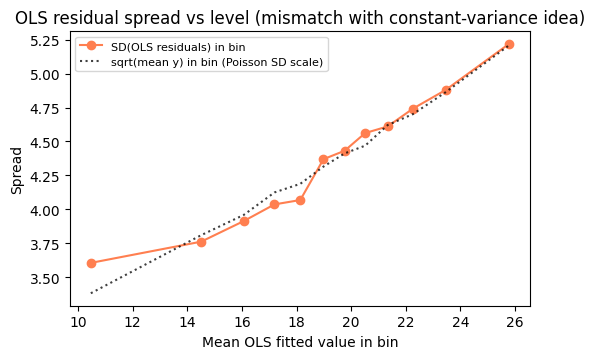

In [29]:
_fit = np.asarray(fitted, dtype=float).ravel()
_res = np.asarray(residuals, dtype=float).ravel()
_y = np.asarray(y, dtype=float).ravel()
_bin = pd.qcut(pd.Series(_fit), q=12, duplicates="drop")
_tab = (
    pd.DataFrame({"f": _fit, "r": _res, "y": _y, "bin": _bin})
    .groupby("bin", observed=True)
    .agg(f_mid=("f", "mean"), r_sd=("r", "std"), y_mean=("y", "mean"))
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(5.5, 3.7))
ax.plot(_tab["f_mid"], _tab["r_sd"], "o-", color="coral", label="SD(OLS residuals) in bin")
ax.plot(
    _tab["f_mid"],
    np.sqrt(np.maximum(_tab["y_mean"], 1e-8)),
    "k:",
    alpha=0.75,
    label="sqrt(mean y) in bin (Poisson SD scale)",
)
ax.set_xlabel("Mean OLS fitted value in bin")
ax.set_ylabel("Spread")
ax.set_title("OLS residual spread vs level (mismatch with constant-variance idea)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


In [30]:
poisson_glm = PoissonRegressor(alpha=0.0, max_iter=1000).fit(X, y)
mu_hat = poisson_glm.predict(X)
print("Intercept:", round(float(poisson_glm.intercept_), 4))
print("Coefficients (temp_high_c, rain_mm):", np.round(poisson_glm.coef_, 4))

y_arr = np.asarray(y, dtype=float).ravel()
pearson_resid = (y_arr - mu_hat) / np.sqrt(np.maximum(mu_hat, 1e-12))
n_obs = len(y_arr)
p_param = 1 + X.shape[1]
chi2_pearson = float(np.sum(pearson_resid**2))
df_resid = n_obs - p_param
dispersion = chi2_pearson / df_resid
print()
print("Pearson χ² (sum of squared Pearson residuals):", round(chi2_pearson, 2))
print("Residual df  n − p  =", df_resid)
print(
    "Dispersion  χ²/(n−p) =",
    round(dispersion, 4),
    "  → near 1 supports Poisson variance; ≫ 1 suggests overdispersion",
)


Intercept: 2.0026
Coefficients (temp_high_c, rain_mm): [ 0.0454 -0.0848]

Pearson χ² (sum of squared Pearson residuals): 11905.34
Residual df  n − p  = 11997
Dispersion  χ²/(n−p) = 0.9924   → near 1 supports Poisson variance; ≫ 1 suggests overdispersion


#### Testing assumptions for the new model

**Pearson residuals** \(r_i = (y_i - \hat\mu_i)/\sqrt{\hat\mu_i}\): the **Q–Q plot** vs normal is an informal check on the GLM’s **mean and variance** structure. **Systematic curves** may mean the **linear predictor** or **Poisson variance** is off. With discrete counts, points rarely sit *exactly* on the diagonal; **large n** and **moderately large** fitted means make the normal approximation more informative. Together with **dispersion χ²/(n−p) ≈ 1** from the previous cell, these support (or challenge) the Poisson model.


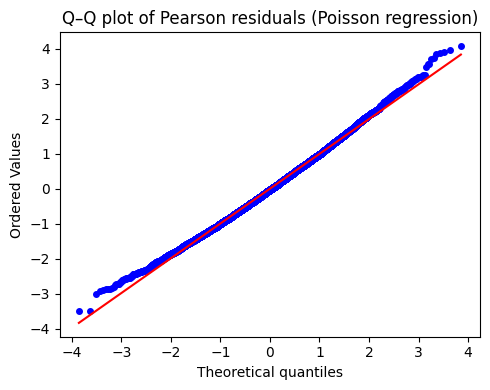

In [31]:
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(pearson_resid, dist="norm", plot=ax)
ax.set_title("Q–Q plot of Pearson residuals (Poisson regression)")
ax.get_lines()[0].set_markersize(4)
plt.tight_layout()
plt.show()
